# 25 — Activity vs Resource Attribution Comparison — BPIC17

Compares Integrated Gradients attributions when the target output is:
1. The predicted **Activity** (next activity)
2. The predicted **Resource** (next resource)

Hypothesis: the attribution profiles do not change much between the two targets,
i.e. the model uses the same input features to predict both.

Analysis:
- **Aggregate**: mean |attribution| per feature, compared side-by-side
- **Per-case**: how often the top-1 (and top-3) most attributed features match

In [1]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
src_path = str(_current / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [2]:
import random
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from src.interpretability.config.bpic17_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

# --- Config ---
TEST_MODE = True
TEST_SAMPLE_SIZE = 50
IG_STEPS = 30
SEED = 42
random.seed(SEED)

TARGET_ACTIVITY = CONFIG.concept_name   # 'Activity'
TARGET_RESOURCE = 'org:resource'

%matplotlib inline

In [3]:
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)
eval_helper = Evaluation(
    model=model, dataset=test_dataset, concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values, all_cat=CONFIG.all_cat, all_num=CONFIG.all_num)
tool = InterpretabilityTool(model, model.data_set_categories, device=device)

print(f'Cases: {len(eval_helper.cases)}')

Data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('Action', 7, {'Created': 1, 'Deleted': 2, 'EOS': 3, 'Obtained': 4, 'Released': 5, 'statechange': 6}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 12, 'User_109': 13, 'User_11': 14, 'User_110': 15, 'U

In [4]:
# Collect prefix-suffix pairs
all_samples = []
for case_name, full_case in tqdm(eval_helper.cases.items(), desc='Collecting'):
    for prefix_len, prefix, suffix in eval_helper._iterate_case(full_case):
        if prefix_len >= 1:
            all_samples.append({
                'case_name': case_name,
                'prefix_len': prefix_len,
                'prefix': prefix,
            })

if TEST_MODE:
    samples = random.sample(all_samples, min(TEST_SAMPLE_SIZE, len(all_samples)))
    print(f'Using {len(samples)} samples (test mode)')
else:
    samples = all_samples
    print(f'Using all {len(samples)} samples')

Collecting:   0%|          | 0/6301 [00:00<?, ?it/s]

Using 50 samples (test mode)


## Compute attributions for both targets

In [5]:
rows_activity = []
rows_resource = []

for sample in tqdm(samples, desc='IG (activity + resource)'):
    prefix = sample['prefix']
    prefix_len = sample['prefix_len']

    cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
    num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
    process = (cat_tensors, num_tensors)

    try:
        attr_act = tool.compute_attribution_map(
            process=process, prefix_length=prefix_len,
            target=TARGET_ACTIVITY, target_class='auto',
            method='integrated_gradients', n_steps=IG_STEPS)

        attr_res = tool.compute_attribution_map(
            process=process, prefix_length=prefix_len,
            target=TARGET_RESOURCE, target_class='auto',
            method='integrated_gradients', n_steps=IG_STEPS)

        # Extract |attribution| per feature per step
        def extract_per_step(attr_map):
            out = {}
            for feat in attr_map.feature_names:
                if feat in attr_map.attributions:
                    vals = attr_map.attributions[feat]
                    if hasattr(vals, 'detach'):
                        vals = vals.detach().cpu().numpy()
                    vals = np.abs(vals).flatten()
                    for step_idx, v in enumerate(vals):
                        step_label = attr_map.step_labels[step_idx] if step_idx < len(attr_map.step_labels) else f't{step_idx}'
                        out[f'{feat}@{step_label}'] = float(v)
            return out

        row_base = {'case_name': sample['case_name'], 'prefix_len': prefix_len}
        rows_activity.append({**row_base, **extract_per_step(attr_act)})
        rows_resource.append({**row_base, **extract_per_step(attr_res)})

    except Exception as e:
        print(f'Error {sample["case_name"]}: {e}')

df_act = pd.DataFrame(rows_activity).fillna(0)
df_res = pd.DataFrame(rows_resource).fillna(0)
feature_step_cols = sorted([c for c in df_act.columns if '@' in c])
print(f'Computed {len(df_act)} attribution pairs, {len(feature_step_cols)} feature-step dimensions')

IG (activity + resource):   0%|          | 0/50 [00:00<?, ?it/s]

Computed 50 attribution pairs, 378 feature-step dimensions


## 1. Aggregate comparison: mean |attribution| per feature

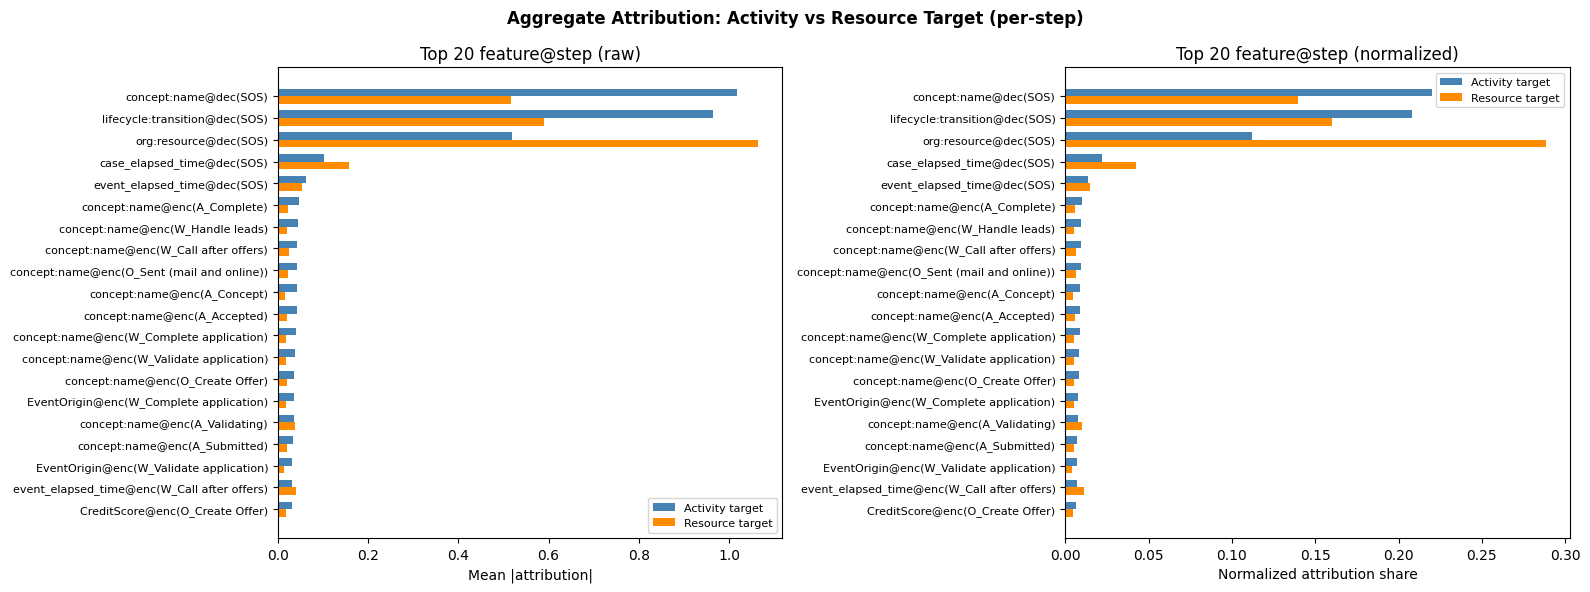

Spearman rank correlation (all 378 feature-steps): 0.984 (p=0.0000)
Pearson correlation:       0.831 (p=0.0000)


In [6]:
# Ensure numeric
act_numeric = df_act[feature_step_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
res_numeric = df_res[feature_step_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

mean_act = act_numeric.mean().sort_values(ascending=False)
mean_res = res_numeric.mean().reindex(mean_act.index)

# Normalize to sum=1 for shape comparison
norm_act = mean_act / mean_act.sum()
norm_res = mean_res / mean_res.sum()

# Show top 20 feature-steps for readability
TOP_N = 20
top_act = mean_act.head(TOP_N)
top_res = mean_res.reindex(top_act.index)

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, TOP_N * 0.3)))

y = np.arange(len(top_act))
h = 0.35

ax = axes[0]
ax.barh(y - h/2, top_act.values, h, label='Activity target', color='steelblue')
ax.barh(y + h/2, top_res.values, h, label='Resource target', color='darkorange')
ax.set_yticks(y)
ax.set_yticklabels(top_act.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Mean |attribution|')
ax.set_title(f'Top {TOP_N} feature@step (raw)')
ax.legend(fontsize=8)

# Normalized
top_norm_act = norm_act.reindex(top_act.index)
top_norm_res = norm_res.reindex(top_act.index)
ax = axes[1]
ax.barh(y - h/2, top_norm_act.values, h, label='Activity target', color='steelblue')
ax.barh(y + h/2, top_norm_res.values, h, label='Resource target', color='darkorange')
ax.set_yticks(y)
ax.set_yticklabels(top_act.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Normalized attribution share')
ax.set_title(f'Top {TOP_N} feature@step (normalized)')
ax.legend(fontsize=8)

plt.suptitle('Aggregate Attribution: Activity vs Resource Target (per-step)', fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation over all feature-step dimensions
from scipy.stats import spearmanr, pearsonr
rho, p_rho = spearmanr(norm_act, norm_res)
r, p_r = pearsonr(norm_act, norm_res)
print(f'Spearman rank correlation (all {len(norm_act)} feature-steps): {rho:.3f} (p={p_rho:.4f})')
print(f'Pearson correlation:       {r:.3f} (p={p_r:.4f})')

## Correlation matrix: Activity vs Resource attribution per feature

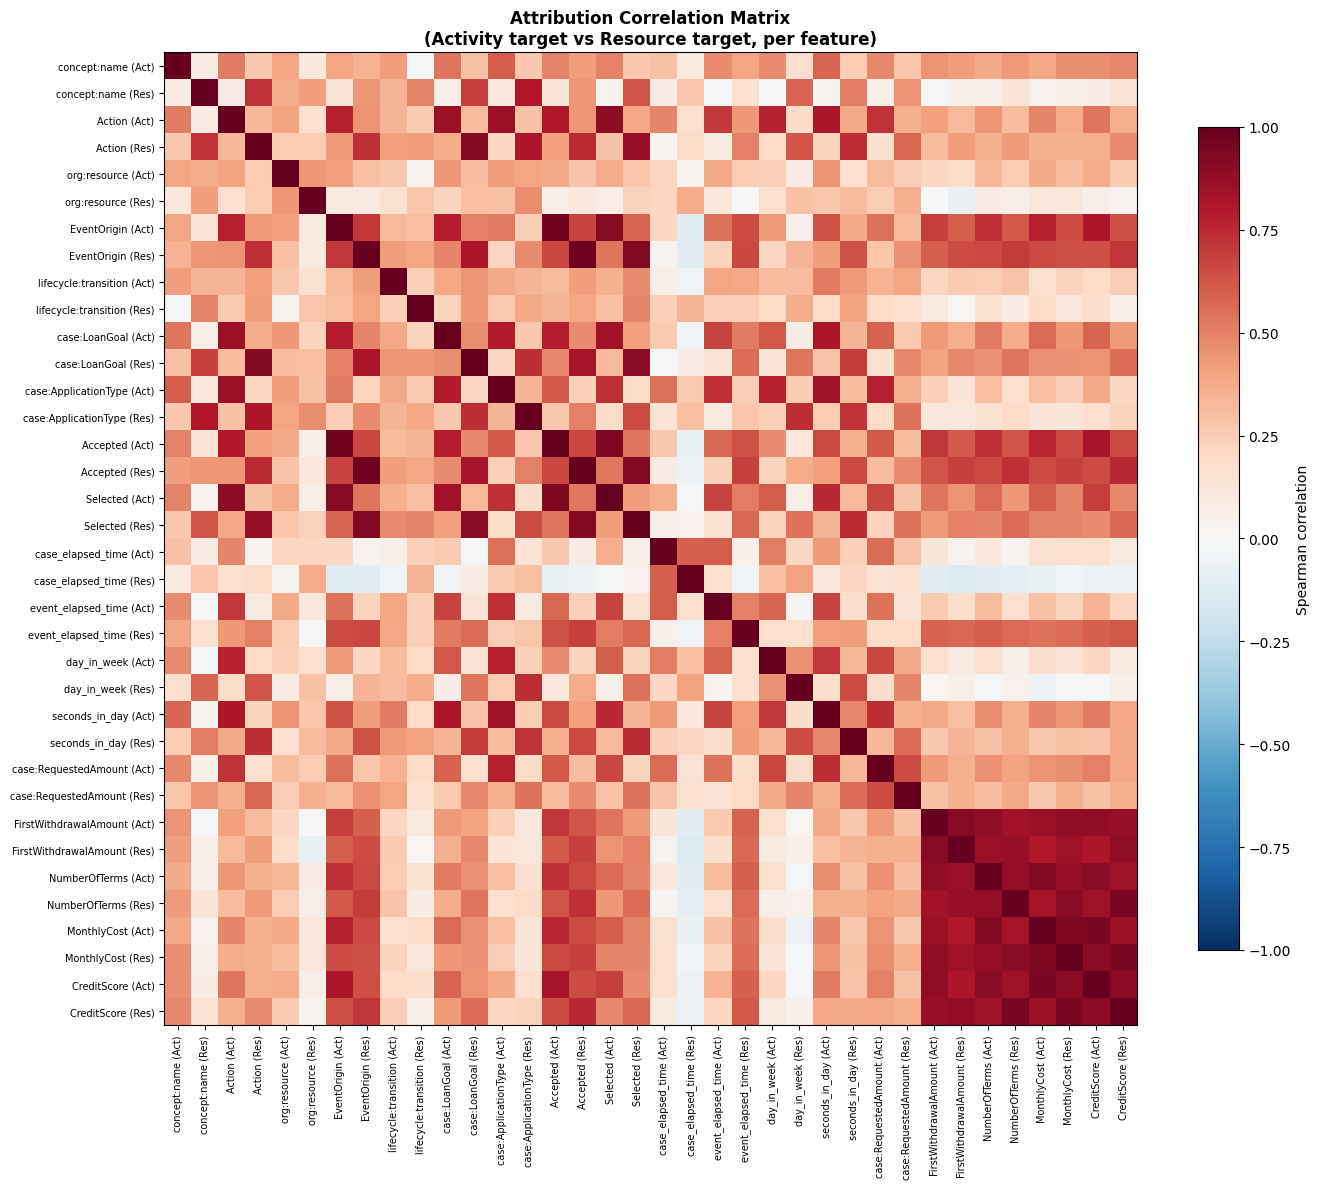

Per-feature cross-target Spearman correlation:
--------------------------------------------------
  concept:name                  : 0.084
  Action                        : 0.332
  org:resource                  : 0.436
  EventOrigin                   : 0.710
  lifecycle:transition          : 0.236
  case:LoanGoal                 : 0.462
  case:ApplicationType          : 0.338
  Accepted                      : 0.671
  Selected                      : 0.417
  case_elapsed_time             : 0.598
  event_elapsed_time            : 0.504
  day_in_week                   : 0.455
  seconds_in_day                : 0.477
  case:RequestedAmount          : 0.655
  FirstWithdrawalAmount         : 0.907
  NumberOfTerms                 : 0.882
  MonthlyCost                   : 0.933
  CreditScore                   : 0.892


In [7]:
# Build per-feature (aggregated over steps) attribution per sample
# so we get one column per feature, not per feature@step
features = [f for f in tool._get_ordered_feature_names()]

act_by_feat = pd.DataFrame(index=range(len(df_act)), columns=features, dtype=float).fillna(0)
res_by_feat = pd.DataFrame(index=range(len(df_res)), columns=features, dtype=float).fillna(0)

for col in feature_step_cols:
    feat = col.rsplit('@', 1)[0]
    if feat in features:
        act_by_feat[feat] += pd.to_numeric(df_act[col], errors='coerce').fillna(0).values
        res_by_feat[feat] += pd.to_numeric(df_res[col], errors='coerce').fillna(0).values

# Combine into a single DataFrame: columns = Feature_Activity, Feature_Resource
combined = pd.DataFrame()
for feat in features:
    combined[f'{feat} (Act)'] = act_by_feat[feat]
    combined[f'{feat} (Res)'] = res_by_feat[feat]

corr = combined.corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr.columns, fontsize=7)
plt.colorbar(im, ax=ax, label='Spearman correlation', shrink=0.8)
ax.set_title('Attribution Correlation Matrix\n(Activity target vs Resource target, per feature)', fontweight='bold')
plt.tight_layout()
plt.show()

# Extract the cross-target block: for each feature, correlation between its Act and Res attribution
print('Per-feature cross-target Spearman correlation:')
print('-' * 50)
for feat in features:
    r = combined[f'{feat} (Act)'].corr(combined[f'{feat} (Res)'], method='spearman')
    print(f'  {feat:30s}: {r:.3f}')

## 2. Per-case comparison: top-1 and top-3 feature overlap

Top-1 match:   6/50 = 12.0%
Top-3 overlap: 92.7% average (mean |intersection|/3)


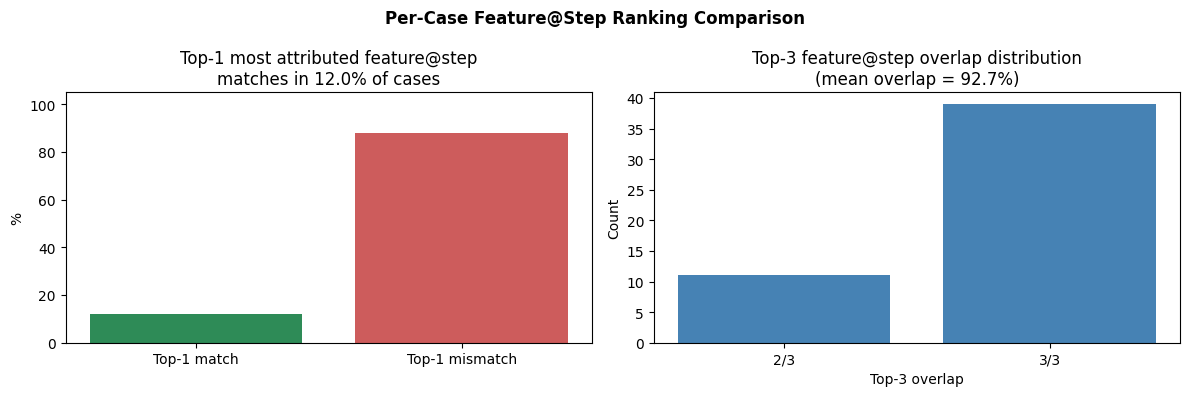

In [8]:
n = len(df_act)
top1_match = 0
top3_overlaps = []

for i in range(n):
    act_vals = act_numeric.iloc[i]
    res_vals = res_numeric.iloc[i]

    top1_act = act_vals.idxmax()
    top1_res = res_vals.idxmax()
    if top1_act == top1_res:
        top1_match += 1

    top3_act = set(act_vals.nlargest(3).index)
    top3_res = set(res_vals.nlargest(3).index)
    top3_overlaps.append(len(top3_act & top3_res) / 3)

top1_pct = top1_match / n * 100
top3_mean = np.mean(top3_overlaps) * 100

print(f'Top-1 match:   {top1_match}/{n} = {top1_pct:.1f}%')
print(f'Top-3 overlap: {top3_mean:.1f}% average (mean |intersection|/3)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(['Top-1 match', 'Top-1 mismatch'], [top1_pct, 100 - top1_pct],
       color=['seagreen', 'indianred'])
ax.set_ylabel('%')
ax.set_title(f'Top-1 most attributed feature@step\nmatches in {top1_pct:.1f}% of cases')
ax.set_ylim(0, 105)

ax = axes[1]
overlap_counts = pd.Series(top3_overlaps).value_counts().sort_index()
labels = {0.0: '0/3', 1/3: '1/3', 2/3: '2/3', 1.0: '3/3'}
ax.bar([labels.get(k, f'{k:.2f}') for k in overlap_counts.index],
       overlap_counts.values, color='steelblue')
ax.set_xlabel('Top-3 overlap')
ax.set_ylabel('Count')
ax.set_title(f'Top-3 feature@step overlap distribution\n(mean overlap = {top3_mean:.1f}%)')

plt.suptitle('Per-Case Feature@Step Ranking Comparison', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Summary

In [9]:
print('=' * 60)
print('SUMMARY: Activity vs Resource Attribution (per-step)')
print('=' * 60)
print(f'Samples:               {n}')
print(f'Feature-step dims:     {len(feature_step_cols)}')
print(f'Spearman (aggregate):  {rho:.3f}')
print(f'Pearson (aggregate):   {r:.3f}')
print(f'Top-1 match rate:      {top1_pct:.1f}%')
print(f'Top-3 mean overlap:    {top3_mean:.1f}%')
print()
if rho > 0.9 and top1_pct > 70:
    print('The attribution profiles are very similar.')
    print('The model uses largely the same features at the same steps for both predictions.')
elif rho > 0.7 and top3_mean > 60:
    print('The attribution profiles are moderately similar.')
    print('The model shares most important feature-steps but with different emphasis.')
else:
    print('The attribution profiles differ meaningfully.')
    print('The model uses different feature-step priorities for Activity vs Resource.')

SUMMARY: Activity vs Resource Attribution (per-step)
Samples:               50
Feature-step dims:     378
Spearman (aggregate):  0.984
Pearson (aggregate):   0.892
Top-1 match rate:      12.0%
Top-3 mean overlap:    92.7%

The attribution profiles are moderately similar.
The model shares most important feature-steps but with different emphasis.
